In [162]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sksurv.datasets import load_whas500
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(0)

# Load data
data, labels = load_whas500()
data = data.join(pd.DataFrame(labels))

# Rename
data.rename(columns={'fstat': 'event', 'lenfol': 'time'}, inplace=True)

# Split
train, test = train_test_split(data, test_size=0.3, random_state=0)

# Encode
features = data.columns.difference(['time', 'event'], sort=False)
cat_features = ['cvd', 'afb', 'sho', 'chf', 'av3', 'miord', 'mitype', 'gender']
num_features = features.difference(cat_features)

# One-hot encode categorical features
ohe = OneHotEncoder(sparse=False, drop='first')  # drop='first' to avoid multicollinearity
train_cat_encoded = ohe.fit_transform(train[cat_features])
test_cat_encoded = ohe.transform(test[cat_features])

# Convert to DataFrame and get column names for the one-hot encoding
train_cat_encoded_df = pd.DataFrame(train_cat_encoded, columns=ohe.get_feature_names_out(cat_features))
test_cat_encoded_df = pd.DataFrame(test_cat_encoded, columns=ohe.get_feature_names_out(cat_features))

# Standard scale numerical features
scaler = StandardScaler()
train_num_scaled = scaler.fit_transform(train[num_features])
test_num_scaled = scaler.transform(test[num_features])

# Convert scaled data to DataFrame
train_num_scaled_df = pd.DataFrame(train_num_scaled, columns=num_features)
test_num_scaled_df = pd.DataFrame(test_num_scaled, columns=num_features)

# Combine the encoded categorical features and scaled numerical features
x_train_df = pd.concat([train_cat_encoded_df, train_num_scaled_df], axis=1)
x_test_df = pd.concat([test_cat_encoded_df, test_num_scaled_df], axis=1)

# Separate labels (time and event) from features
y_train_df = train[['time', 'event']]
y_test_df = test[['time', 'event']]

c:\Users\cml\miniconda3\envs\py39-pyro\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [163]:
x_train_df

,cvd_1,afb_1,sho_1,chf_1,av3_1,miord_1,mitype_1,gender_1,age,bmi,diasbp,hr,los,sysbp
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.153099,-0.431146,0.564707,-0.197616,-0.630903,-1.054596
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.828607,-1.733651,0.115202,-1.214758,0.628504,2.204037
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.743091,0.472102,0.250053,1.200954,-0.421002,-0.597779
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.896941,2.797205,0.474806,0.141431,-0.211101,0.468129
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.016429,-1.031605,1.283916,-0.621425,-0.211101,1.077220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.101945,-1.970349,-0.334304,-0.197616,0.418603,-0.750051
346,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.948095,-1.164324,0.160152,-0.621425,-0.001199,-0.019143
347,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.128079,2.436307,-0.604007,-0.663806,0.628504,-0.780506
348,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.494772,-0.419456,1.014212,1.031430,1.468108,0.772674


In [164]:
y_train_df

,time,event
141,1934.0,False
383,631.0,False
135,1831.0,False
493,69.0,True
122,1847.0,False
...,...,...
323,19.0,True
192,1298.0,False
117,1931.0,False
47,2032.0,False


In [165]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from typing import List, Tuple, Optional, Union

## Utility functions

In [166]:
import math

Numeric = Union[float, int, bool]
NumericArrayLike = Union[List[Numeric], Tuple[Numeric], np.ndarray, pd.Series, pd.DataFrame, torch.Tensor]

def encode_survival(
        time: Union[float, int, NumericArrayLike],
        event: Union[int, bool, NumericArrayLike],
        bins: NumericArrayLike
) -> torch.Tensor:
    # TODO this should handle arrays and (CUDA) tensors
    if isinstance(time, (float, int, np.ndarray)):
        time = np.atleast_1d(time)
        time = torch.tensor(time)
    if isinstance(event, (int, bool, np.ndarray)):
        event = np.atleast_1d(event)
        event = torch.tensor(event)

    if isinstance(bins, np.ndarray):
        bins = torch.tensor(bins)

    try:
        device = bins.device
    except AttributeError:
        device = "cpu"

    time = np.clip(time, 0, bins.max())
    # add extra bin [max_time, inf) at the end
    y = torch.zeros((time.shape[0], bins.shape[0] + 1),
                    dtype=torch.float,
                    device=device)
    # For some reason, the `right` arg in torch.bucketize
    # works in the _opposite_ way as it does in numpy,
    # so we need to set it to True
    bin_idxs = torch.bucketize(time, bins, right=True)
    for i, (bin_idx, e) in enumerate(zip(bin_idxs, event)):
        if e == 1:
            y[i, bin_idx] = 1
        else:
            y[i, bin_idx:] = 1
    return y.squeeze()

def reformat_survival(
        dataset: pd.DataFrame,
        time_bins: NumericArrayLike
) -> (torch.Tensor, torch.Tensor):
    x = torch.tensor(dataset.drop(["time", "event"], axis=1).values, dtype=torch.float)
    y = encode_survival(dataset["time"].values, dataset["event"].values, time_bins)
    return x, y

def make_time_bins(
        times: NumericArrayLike,
        num_bins: Optional[int] = None,
        use_quantiles: bool = True,
        event: Optional[NumericArrayLike] = None
) -> torch.Tensor:
    # TODO this should handle arrays and (CUDA) tensors
    if event is not None:
        times = times[event == 1]
    if num_bins is None:
        num_bins = math.ceil(math.sqrt(len(times)))
    if use_quantiles:
        # NOTE we should switch to using torch.quantile once it becomes
        # available in the next version
        bins = np.unique(np.quantile(times, np.linspace(0, 1, num_bins)))
    else:
        bins = np.linspace(times.min(), times.max(), num_bins)
    bins = torch.tensor(bins, dtype=torch.float)
    return bins

def compute_unique_counts(
        event: torch.Tensor,
        time: torch.Tensor,
        order: Optional[torch.Tensor] = None):
    """Count right censored and uncensored samples at each unique time point."""
    n_samples = event.shape[0]

    if order is None:
        order = torch.argsort(time)

    uniq_times = torch.empty(n_samples, dtype=time.dtype, device=time.device)
    uniq_events = torch.empty(n_samples, dtype=torch.int, device=time.device)
    uniq_counts = torch.empty(n_samples, dtype=torch.int, device=time.device)

    i = 0
    prev_val = time[order[0]]
    j = 0
    while True:
        count_event = 0
        count = 0
        while i < n_samples and prev_val == time[order[i]]:
            if event[order[i]]:
                count_event += 1

            count += 1
            i += 1

        uniq_times[j] = prev_val
        uniq_events[j] = count_event
        uniq_counts[j] = count
        j += 1

        if i == n_samples:
            break

        prev_val = time[order[i]]

    uniq_times = uniq_times[:j]
    uniq_events = uniq_events[:j]
    uniq_counts = uniq_counts[:j]
    n_censored = uniq_counts - uniq_events

    # offset cumulative sum by one
    total_count = torch.cat([torch.tensor([0], device=uniq_counts.device), uniq_counts], dim=0)
    n_at_risk = n_samples - torch.cumsum(total_count, dim=0)

    return uniq_times, uniq_events, n_at_risk[:-1], n_censored

def make_monotonic(
        array: Union[torch.Tensor, np.ndarray, list]
):
    for i in range(len(array) - 1):
        if not array[i] >= array[i + 1]:
            array[i + 1] = array[i]
    return array

def baseline_hazard(
        logits: torch.Tensor,
        time: torch.Tensor,
        event: torch.Tensor
) -> (torch.Tensor, torch.Tensor, torch.Tensor):
    risk_score = torch.exp(logits)
    order = torch.argsort(time)
    risk_score = risk_score[order]
    uniq_times, n_events, n_at_risk, _ = compute_unique_counts(event, time, order)

    divisor = torch.empty(n_at_risk.shape, dtype=torch.float, device=n_at_risk.device)
    value = torch.sum(risk_score)
    divisor[0] = value
    k = 0
    for i in range(1, len(n_at_risk)):
        d = n_at_risk[i - 1] - n_at_risk[i]
        value -= risk_score[k:(k + d)].sum()
        k += d
        divisor[i] = value

    assert k == n_at_risk[0] - n_at_risk[-1]

    hazard = n_events / divisor
    
    # Make sure the survival curve always starts at 1
    if 0 not in uniq_times:
        uniq_times = torch.cat([torch.tensor([0]).to(uniq_times.device), uniq_times], 0)
        hazard = torch.cat([torch.tensor([0]).to(hazard.device), hazard], 0)
        
    cum_baseline_hazard = torch.cumsum(hazard.cpu(), dim=0).to(hazard.device)
    baseline_survival = torch.exp(- cum_baseline_hazard)
    if baseline_survival.isinf().any():
        print(f"Baseline survival contains \'inf\', need attention. \n"
              f"Baseline survival distribution: {baseline_survival}")
        last_zero = torch.where(baseline_survival == 0)[0][-1].item()
        baseline_survival[last_zero + 1:] = 0
    baseline_survival = make_monotonic(baseline_survival)
    return uniq_times, cum_baseline_hazard, baseline_survival

## Loss function

In [167]:
# Cox NLL function
def cox_nll(
        risk_pred: torch.Tensor,
        true_times: torch.Tensor,
        true_indicator: torch.Tensor
) -> torch.Tensor:
    eps = 1e-20
    risk_pred = risk_pred.reshape(-1, 1)
    true_times = true_times.reshape(-1, 1)
    true_indicator = true_indicator.reshape(-1, 1)
    mask = torch.ones(true_times.shape[0], true_times.shape[0]).to(true_times.device)
    mask[(true_times.T - true_times) > 0] = 0
    max_risk = risk_pred.max()
    log_loss = torch.exp(risk_pred - max_risk) * mask
    log_loss = torch.sum(log_loss, dim=0)
    log_loss = torch.log(log_loss + eps).reshape(-1, 1) + max_risk
    neg_log_loss = -torch.sum((risk_pred - log_loss) * true_indicator) / torch.sum(true_indicator)
    return neg_log_loss

# Sample ELBO function
def sample_elbo(self, x, t, e, dataset_size) -> (torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor):
    n_samples = self.config.n_samples_train
    outputs = self(x, sample=True, n_samples=n_samples)
    log_prior = self.log_prior() / n_samples
    log_variational_posterior = self.log_variational_posterior() / n_samples
    nll = cox_nll(outputs.mean(dim=0), t, e, model=self, C1=0)
    
    loss = (log_variational_posterior - log_prior) / (dataset_size) + nll # KL divergence + NLL
    
    return loss

## Define the network

In [168]:
# BNN
class BNN(PyroModule):
    def __init__(self, in_dim=1, out_dim=1, hid_dim=32, n_hid_layers=1, prior_scale=5.):
        super().__init__()
        
        self.in_dim = in_dim
        self.time_bins = None
        self.cum_baseline_hazard = None
        self.baseline_survival = None

        self.activation = nn.ReLU()
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # Define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., prior_scale * np.sqrt(2 / self.layer_sizes[layer_idx])).expand(
                [self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., prior_scale).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, t=None, e=None):
        x = x.reshape(-1, self.in_dim)
        x = self.activation(self.layers[0](x))  # input --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))  # hidden --> hidden
        mu = self.layers[-1](x).squeeze()
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))  # infer the response noise
        
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=t) #TODO: I have times (t) and events (e). How do I use that as obs?
            
        return mu

    def calculate_baseline_survival(self, x, t, e):
        outputs = self.forward(x) # mean
        self.time_bins, self.cum_baseline_hazard, self.baseline_survival = baseline_hazard(outputs, t, e)

## Training the network with mean-field VI

In [169]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange

x_train, t_train, e_train = (torch.tensor(x_train_df.values, dtype=torch.float),
                             torch.tensor(y_train_df["time"].values, dtype=torch.float),
                             torch.tensor(y_train_df["event"].values, dtype=torch.float))

x_test, t_test, e_test = (torch.tensor(x_test_df.values, dtype=torch.float),
                          torch.tensor(y_test_df["time"].values, dtype=torch.float),
                          torch.tensor(y_test_df["event"].values, dtype=torch.float))

model = BNN(in_dim=x_train.shape[1], hid_dim=32, n_hid_layers=1, prior_scale=5.)
mean_field_guide = AutoDiagonalNormal(model)
optimizer = pyro.optim.Adam({"lr": 0.01})

elbo_loss_fn = Trace_ELBO().differentiable_loss
def loss_fn(model, guide, x_train, t_train, e_train):
    n = x_train.shape[0]
    elbo_loss = elbo_loss_fn(model, guide, x_train, t_train, e_train)
    risk_scores = model(x_train)
    cox_loss = cox_nll(risk_scores, t_train, e_train)
    total_loss = elbo_loss + cox_loss
    return (total_loss / n)

svi = SVI(model, mean_field_guide, optimizer, loss=loss_fn)
pyro.clear_param_store()

num_epochs = 1000
progress_bar = trange(num_epochs)

store_elbo = []
for epoch in progress_bar:
    loss = svi.step(x_train, t_train, e_train)
    norm_loss = loss / x_train.shape[0]
    store_elbo.append(norm_loss)
    progress_bar.set_postfix(loss=f"{norm_loss:.3f}")
    
model.calculate_baseline_survival(x_train, t_train, e_train)

100%|██████████| 1000/1000 [00:06<00:00, 165.09it/s, loss=3659.570] 


## Plot the evolution of the loss

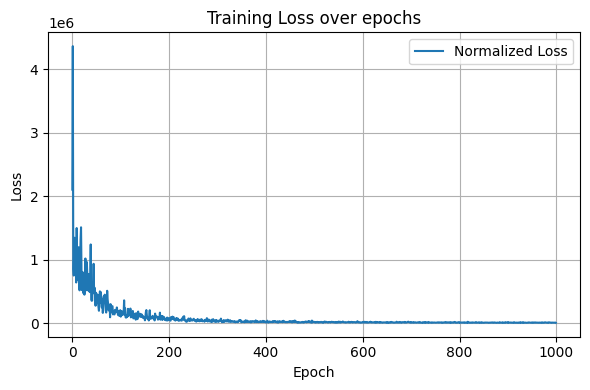

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(store_elbo, label='Normalized Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluation

In [171]:
from pyro.infer import Predictive

def cox_survival(
        baseline_survival: torch.Tensor,
        linear_predictor: torch.Tensor
) -> torch.Tensor:
    n_sample = linear_predictor.shape[0]
    n_data = linear_predictor.shape[1]
    risk_score = torch.exp(linear_predictor)
    survival_curves = torch.empty((n_sample, n_data, baseline_survival.shape[0]), dtype=torch.float).to(linear_predictor.device)
    for i in range(n_sample):
        for j in range(n_data):
            survival_curves[i, j, :] = torch.pow(baseline_survival, risk_score[i, j])
    return survival_curves

def make_ensemble_cox_prediction(
        model: PyroModule,
        x: torch.Tensor,
        n_samples_test: int
) -> (torch.Tensor, torch.Tensor, torch.Tensor):
    model.eval()
    with torch.no_grad():
        predictive = Predictive(model, guide=mean_field_guide, num_samples=n_samples_test)
        preds = predictive(x)['obs']
        survival_outputs = cox_survival(model.baseline_survival, preds)
        mean_survival_outputs = survival_outputs.mean(dim=0)
        
    time_bins = model.time_bins
    return mean_survival_outputs, time_bins, survival_outputs

# Make survival predictions
survival_outputs, time_bins, ensemble_outputs = make_ensemble_cox_prediction(model, x_test, n_samples_test=100)

In [176]:
survival_outputs

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [173]:
from pyro.infer import Predictive
from SurvivalEVAL import SurvivalEvaluator

# Obtain predictions
predictive = Predictive(model, guide=mean_field_guide, num_samples=100)
preds = predictive(x_test)
y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
y_std = preds['obs'].T.detach().numpy().std(axis=1)

In [174]:
y_pred

array([ 631.21375,  901.9215 ,  801.79016,  613.0704 , 1137.0793 ,
        905.8604 ,  938.5593 ,  506.77283,  636.96014, 1622.8492 ,
        634.23706,  170.23027,  998.3193 , 1147.8324 ,  738.0402 ,
        773.845  ,  972.78406, 1285.2378 ,  756.8108 ,  659.4956 ,
        322.01202, 1025.6879 ,  416.62057,  721.62744,  910.6401 ,
       1129.554  ,  613.65454, 1374.0375 ,  832.34125,  816.611  ,
        826.155  ,  698.5717 ,  683.06305, 1218.0366 ,  861.52625,
        233.82115, 1226.3126 ,  732.492  , 1257.4086 ,  693.96893,
        940.2919 ,  546.03784,  240.41011,  535.63885, 1185.962  ,
       1098.6188 ,  427.97815,  749.46893,  829.329  , 1152.2163 ,
       1414.162  , 1096.4996 ,  758.7537 , 1689.4014 ,  510.04016,
        944.6665 , 1017.00836,  965.72943,  479.80582, 1186.6116 ,
        804.4412 , 1388.0947 ,  385.71457,  782.99365, 1295.7616 ,
        977.805  , 1040.3031 ,  594.83484,  524.98517,  857.8544 ,
        769.29474,  683.0511 ,  682.92377,  654.4654 ,  551.58

In [175]:
y_std

array([ 9.205592 ,  7.602467 ,  7.2673035,  6.47988  ,  8.540138 ,
        8.099946 ,  7.8271995,  4.7640166,  8.552624 , 12.622426 ,
        6.581427 ,  3.9018886,  8.971432 ,  9.033504 ,  6.579717 ,
        8.120392 , 13.291175 , 10.956077 ,  8.482328 ,  6.971547 ,
        5.4154005,  8.29381  ,  9.5490885,  6.7758474,  9.256588 ,
        8.276937 ,  9.021239 ,  9.924811 , 12.219085 ,  7.29546  ,
        6.9223347,  6.5817585,  5.8998556, 10.502733 ,  9.58233  ,
        5.696818 , 10.984901 ,  9.948393 , 11.635183 ,  9.193828 ,
        9.515427 ,  7.070966 ,  3.6142218,  7.247977 , 10.605668 ,
        9.283014 ,  6.024561 ,  9.957659 ,  8.814107 , 12.086861 ,
       11.736701 ,  9.449816 , 11.62704  , 12.13171  ,  5.2928877,
        7.2532787,  9.720584 ,  7.943263 ,  5.893837 ,  9.5277405,
        7.5036187, 10.991876 ,  6.114591 ,  6.4419436, 10.078647 ,
       10.176405 ,  8.243209 ,  8.675423 ,  7.2282934,  9.920075 ,
        7.169494 ,  7.9979205,  6.8376794,  7.0482993,  6.8450